<a href="https://colab.research.google.com/github/rodrigoviannasn/MAT-422/blob/main/MAT422_HW_2_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAT 422 — Homework 2.4: Maximum Likelihood Estimation and Linear Regression

Rodrigo Vianna | 10/3/2026

In [11]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(424)
np.set_printoptions(precision=4, suppress=True)

## 2.4.1 Maximum Likelihood Estimation for Random Samples

Maximum likelihood estimation, or MLE, finds parameter values that make the observed sample most likely under a chosen probability model.

For a random sample from a normal distribution,

$$
X_1, X_2, \ldots, X_n \sim N(\mu, \sigma^2),
$$

the MLE of the mean is the sample mean:

$$
\hat{\mu}_{MLE}=\frac{1}{n}\sum_{i=1}^{n}x_i.
$$

The MLE of the variance uses a denominator of $n$:

$$
\hat{\sigma}_{MLE}^2=\frac{1}{n}\sum_{i=1}^{n}(x_i-\hat{\mu}_{MLE})^2.
$$

This example generates a normal random sample, estimates its mean and standard deviation, and shows where the likelihood is maximized.

In [12]:
true_mean = 18.0
true_standard_deviation = 3.0
sample_size = 40

random_sample_mle = rng.normal(
    loc=true_mean,
    scale=true_standard_deviation,
    size=sample_size
)

mean_mle = np.mean(random_sample_mle)
variance_mle = np.mean((random_sample_mle - mean_mle)**2)
standard_deviation_mle = np.sqrt(variance_mle)

def normal_log_likelihood(data, mean, standard_deviation):
    n = len(data)

    return (
        -n * np.log(standard_deviation * np.sqrt(2 * np.pi))
        - np.sum((data - mean)**2) / (2 * standard_deviation**2)
    )

log_likelihood_mle = normal_log_likelihood(
    random_sample_mle,
    mean_mle,
    standard_deviation_mle
)

print("First 10 observations from the random sample:")
print(random_sample_mle[:10])

print("\nActual population mean:", true_mean)
print("Actual population standard deviation:", true_standard_deviation)

print("\nMLE estimated mean:", mean_mle)
print("MLE estimated variance:", variance_mle)
print("MLE estimated standard deviation:", standard_deviation_mle)

print("\nLog-likelihood at the MLE estimates:")
print(log_likelihood_mle)

First 10 observations from the random sample:
[12.2724 18.1578 18.9579 20.6331 17.6193 20.0813 20.3357 17.825  18.3436
 22.2322]

Actual population mean: 18.0
Actual population standard deviation: 3.0

MLE estimated mean: 18.90794666752901
MLE estimated variance: 9.549070671630572
MLE estimated standard deviation: 3.0901570626151953

Log-likelihood at the MLE estimates:
-101.88641808591464


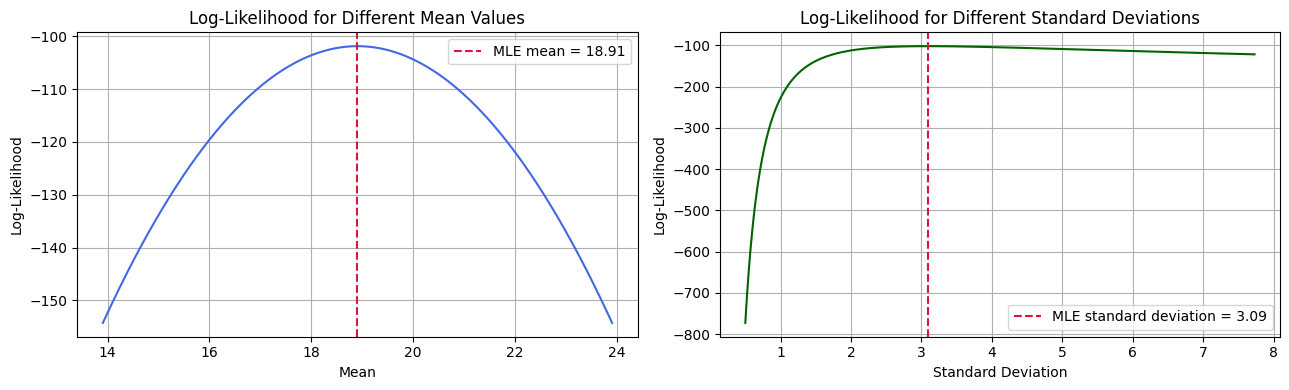

In [13]:
mean_values = np.linspace(mean_mle - 5, mean_mle + 5, 300)
standard_deviation_values = np.linspace(
    0.5,
    max(6, standard_deviation_mle * 2.5),
    300
)

log_likelihood_by_mean = np.array([
    normal_log_likelihood(
        random_sample_mle,
        mean,
        standard_deviation_mle
    )
    for mean in mean_values
])

log_likelihood_by_standard_deviation = np.array([
    normal_log_likelihood(
        random_sample_mle,
        mean_mle,
        standard_deviation
    )
    for standard_deviation in standard_deviation_values
])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(
    mean_values,
    log_likelihood_by_mean,
    color="royalblue"
)

axes[0].axvline(
    mean_mle,
    color="crimson",
    linestyle="--",
    label=f"MLE mean = {mean_mle:.2f}"
)

axes[0].set_title("Log-Likelihood for Different Mean Values")
axes[0].set_xlabel("Mean")
axes[0].set_ylabel("Log-Likelihood")
axes[0].legend()
axes[0].grid()

axes[1].plot(
    standard_deviation_values,
    log_likelihood_by_standard_deviation,
    color="darkgreen"
)

axes[1].axvline(
    standard_deviation_mle,
    color="crimson",
    linestyle="--",
    label=f"MLE standard deviation = {standard_deviation_mle:.2f}"
)

axes[1].set_title("Log-Likelihood for Different Standard Deviations")
axes[1].set_xlabel("Standard Deviation")
axes[1].set_ylabel("Log-Likelihood")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

### Section Conclusion

This example showed how MLE can estimate the mean and standard deviation of a normal random sample. The likelihood graphs reached their highest values at the MLE estimates, which means that these parameter values made the observed data most likely. It was helpful to see that MLE uses the actual sample data instead of simply using the original population parameters.

## 2.4.2 Linear Regression

Linear regression models the relationship between an input variable $x$ and an output variable $y$ with a best-fit line:

$$
\hat{y}=\beta_0+\beta_1x.
$$

The intercept $\beta_0$ is the predicted value of $y$ when $x=0$, while the slope $\beta_1$ describes the expected change in $y$ for each one-unit increase in $x$.

When the residual errors are assumed to be normally distributed, the least-squares regression coefficients are also maximum likelihood estimates. This example models the relationship between practice hours and assessment scores.

In [14]:
practice_hours = np.array([
    1, 2, 3, 4, 5,
    6, 7, 8, 9, 10
], dtype=float)

assessment_scores = np.array([
    50, 55, 60, 64, 68,
    72, 76, 79, 84, 87
], dtype=float)

design_matrix = np.column_stack((
    np.ones_like(practice_hours),
    practice_hours
))

beta_hat = np.linalg.lstsq(
    design_matrix,
    assessment_scores,
    rcond=None
)[0]

intercept_mle, slope_mle = beta_hat

predicted_scores = design_matrix @ beta_hat
residuals = assessment_scores - predicted_scores

residual_sum_of_squares = np.sum(residuals**2)
total_sum_of_squares = np.sum(
    (assessment_scores - np.mean(assessment_scores))**2
)

r_squared = 1 - (
    residual_sum_of_squares /
    total_sum_of_squares
)

residual_standard_deviation_mle = np.sqrt(
    np.mean(residuals**2)
)

prediction_hours = 6.5
predicted_score = (
    intercept_mle +
    slope_mle * prediction_hours
)

print("Intercept estimate:", intercept_mle)
print("Slope estimate:", slope_mle)

print(
    "\nRegression equation:"
    f"\nPredicted score = {intercept_mle:.2f}"
    f" + {slope_mle:.2f}(practice hours)"
)

print("\nR-squared:", r_squared)
print("Residual standard deviation MLE:",
      residual_standard_deviation_mle)

print(
    f"\nPredicted score for {prediction_hours} practice hours:"
    f" {predicted_score:.2f}"
)

Intercept estimate: 47.133333333333304
Slope estimate: 4.0666666666666735

Regression equation:
Predicted score = 47.13 + 4.07(practice hours)

R-squared: 0.9969796614297893
Residual standard deviation MLE: 0.6429100507328616

Predicted score for 6.5 practice hours: 73.57


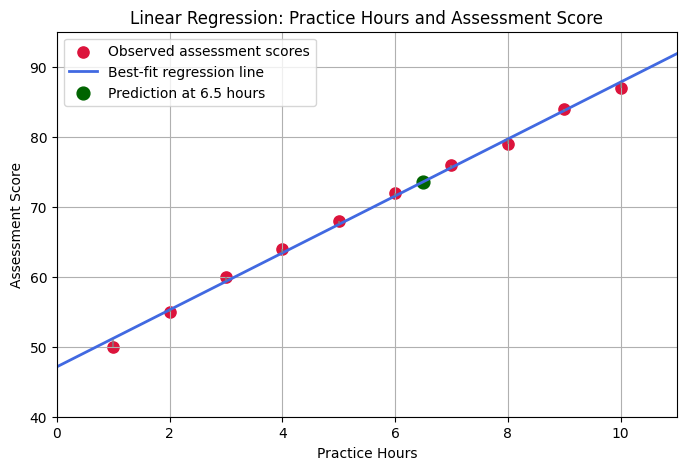

In [15]:
line_x = np.linspace(0, 11, 200)
line_y = intercept_mle + slope_mle * line_x

plt.figure(figsize=(8, 5))

plt.scatter(
    practice_hours,
    assessment_scores,
    color="crimson",
    s=65,
    label="Observed assessment scores"
)

plt.plot(
    line_x,
    line_y,
    color="royalblue",
    linewidth=2,
    label="Best-fit regression line"
)

for x_value, actual_score, predicted_score_value in zip(
    practice_hours,
    assessment_scores,
    predicted_scores
):
    plt.plot(
        [x_value, x_value],
        [actual_score, predicted_score_value],
        color="gray",
        linestyle="--",
        alpha=0.7
    )

plt.scatter(
    prediction_hours,
    predicted_score,
    color="darkgreen",
    s=85,
    label=f"Prediction at {prediction_hours} hours"
)

plt.xlabel("Practice Hours")
plt.ylabel("Assessment Score")
plt.title("Linear Regression: Practice Hours and Assessment Score")
plt.xlim(0, 11)
plt.ylim(40, 95)
plt.grid()
plt.legend()
plt.show()

### Section Conclusion

The linear regression model showed a strong positive relationship between practice hours and assessment scores. The positive slope means that the predicted score increases as practice hours increase. The residual lines on the graph show the differences between the actual scores and the values predicted by the regression line. I also learned that least squares and MLE are connected when the residual errors are normally distributed.

## Conclusion / Reflection

Maximum likelihood estimation and linear regression both use sample data to estimate unknown values. In the first section, MLE estimated the mean and standard deviation that made a normal random sample most likely. In the second section, linear regression estimated a best-fit line that described the relationship between practice hours and assessment scores.

Linear regression can also be understood as a maximum likelihood method when the errors are normally distributed. Using Python made it easier to calculate the estimates, observe the likelihood graphs, and visualize how the regression line fits the data. MLE and linear regression are both useful tools for making predictions and learning from random samples.